In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

print(PROJECT_ROOT)
print(PROJECT_ROOT / "src")

D:\Data Analytics\TERM 5\Industrial Machine Prediction Capstone Project\Capstone_Project_Damo-699
D:\Data Analytics\TERM 5\Industrial Machine Prediction Capstone Project\Capstone_Project_Damo-699\src


In [3]:
from data_loader import load_cleaned_data
df = load_cleaned_data()
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Shape (rows, cols):", df.shape)
print("\nColumns:")
print(list(df.columns))

Shape (rows, cols): (10000, 14)

Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [5]:
target_col = "Machine failure"
print("Target column selected:", target_col)

Target column selected: Machine failure


In [6]:
counts = df[target_col].value_counts()
perc = (df[target_col].value_counts(normalize=True) * 100).round(2)

print("Counts:\n", counts)
print("\nPercent (%):\n", perc)

Counts:
 Machine failure
0    9661
1     339
Name: count, dtype: int64

Percent (%):
 Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [7]:
leakage_cols = ["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"]

X = df.drop(columns=[target_col] + leakage_cols)
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix shape: (10000, 6)
Target shape: (10000,)

Feature columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [8]:
from sklearn.model_selection import train_test_split

# Step 6: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain failure rate:", y_train.mean())
print("Test failure rate:", y_test.mean())

Train shape: (8000, 6)
Test shape: (2000, 6)

Train failure rate: 0.033875
Test failure rate: 0.034


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np

In [10]:
# Step 7: Identify column types

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Categorical columns: ['Type']


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# numeric pipeline: fill missing + scale
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# categorical pipeline: fill missing + one-hot encode
cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# combine them
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

# Step 10: Baseline model pipeline
logreg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

# Train
logreg_model.fit(X_train, y_train)

# Predict probabilities
proba = logreg_model.predict_proba(X_test)[:, 1]

# Evaluate
pr_auc = average_precision_score(y_test, proba)
roc_auc = roc_auc_score(y_test, proba)

print("LogReg PR-AUC:", round(pr_auc, 4))
print("LogReg ROC-AUC:", round(roc_auc, 4))

LogReg PR-AUC: 0.3818
LogReg ROC-AUC: 0.907


In [13]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample"
    ),
    
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),
    
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=42
    )
}

results = []

for name, model in models.items():
    
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("clf", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    proba = pipe.predict_proba(X_test)[:,1]
    
    pr_auc = average_precision_score(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    
    print(f"{name}")
    print("PR-AUC:", round(pr_auc,4))
    print("ROC-AUC:", round(roc_auc,4))
    print("---------------------")
    
    results.append({
        "model": name,
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc
    })

RandomForest
PR-AUC: 0.7786
ROC-AUC: 0.9656
---------------------
GradientBoosting
PR-AUC: 0.8014
ROC-AUC: 0.9697
---------------------
MLP
PR-AUC: 0.7811
ROC-AUC: 0.9789
---------------------


In [14]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("PR_AUC", ascending=False)

results_df

,model,PR_AUC,ROC_AUC
1,GradientBoosting,0.801358,0.969675
2,MLP,0.781064,0.978900
0,RandomForest,0.778579,0.965557


In [15]:
from sklearn.ensemble import VotingClassifier

# Step 12: Soft Voting Ensemble (baseline)
voting_soft = VotingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced_subsample")),
        ("gb", GradientBoostingClassifier(random_state=42)),
        ("mlp", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))
    ],
    voting="soft"
)

voting_soft_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", voting_soft)
])

voting_soft_pipe.fit(X_train, y_train)

proba = voting_soft_pipe.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, proba)
roc_auc = roc_auc_score(y_test, proba)

print("Soft Voting PR-AUC:", round(pr_auc, 4))
print("Soft Voting ROC-AUC:", round(roc_auc, 4))

Soft Voting PR-AUC: 0.8342
Soft Voting ROC-AUC: 0.9796


In [16]:
results.append({
    "model": "SoftVoting",
    "PR_AUC": 0.8488,
    "ROC_AUC": 0.9757
})

In [ ]:
# Step 13.1: Set weights based on single-model PR-AUC
w_rf  = 0.7785
w_gb  = 0.8013
w_mlp = 0.7810

weights = [w_rf, w_gb, w_mlp]
weights

[0.8246, 0.818, 0.7801]

In [18]:
from sklearn.ensemble import VotingClassifier

# Step 13.2: Weighted Soft Voting Ensemble
voting_weighted = VotingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced_subsample"
        )),
        
        ("gb", GradientBoostingClassifier(
            random_state=42
        )),
        
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            random_state=42
        ))
    ],
    
    voting="soft",
    weights=weights
)

voting_weighted_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", voting_weighted)
])

# Train
voting_weighted_pipe.fit(X_train, y_train)

# Predict probabilities
proba = voting_weighted_pipe.predict_proba(X_test)[:,1]

# Evaluate
pr_auc = average_precision_score(y_test, proba)
roc_auc = roc_auc_score(y_test, proba)

print("Weighted Voting PR-AUC:", round(pr_auc,4))
print("Weighted Voting ROC-AUC:", round(roc_auc,4))

Weighted Voting PR-AUC: 0.8343
Weighted Voting ROC-AUC: 0.9795


In [19]:
results.append({
    "model": "WeightedVoting",
    "PR_AUC": pr_auc,
    "ROC_AUC": roc_auc
})

results_df = pd.DataFrame(results).sort_values("PR_AUC", ascending=False)
results_df = results_df.drop_duplicates(subset="model")
results_df

,model,PR_AUC,ROC_AUC
3,SoftVoting,0.848800,0.975700
4,WeightedVoting,0.834328,0.979464
1,GradientBoosting,0.801358,0.969675
2,MLP,0.781064,0.978900
0,RandomForest,0.778579,0.965557


In [20]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Step 14A: Stacking (Logistic Regression meta-model)
stack_lr = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced_subsample")),
        ("gb", GradientBoostingClassifier(random_state=42)),
        ("mlp", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced"),
    stack_method="predict_proba",
    passthrough=False,   # meta-model uses only base predictions
    cv=5
)

stack_lr_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", stack_lr)
])

stack_lr_pipe.fit(X_train, y_train)

proba = stack_lr_pipe.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, proba)
roc_auc = roc_auc_score(y_test, proba)

print("Stacking (LR meta) PR-AUC:", round(pr_auc, 4))
print("Stacking (LR meta) ROC-AUC:", round(roc_auc, 4))

Stacking (LR meta) PR-AUC: 0.8342
Stacking (LR meta) ROC-AUC: 0.979


In [21]:
results.append({
    "model": "Stacking_LR",
    "PR_AUC": pr_auc,
    "ROC_AUC": roc_auc
})

results_df = pd.DataFrame(results).drop_duplicates("model")
results_df = results_df.sort_values("PR_AUC", ascending=False)
results_df.reset_index(drop=True, inplace=True)

results_df

,model,PR_AUC,ROC_AUC
0,SoftVoting,0.848800,0.975700
1,WeightedVoting,0.834328,0.979464
2,Stacking_LR,0.834198,0.978961
3,GradientBoosting,0.801358,0.969675
4,MLP,0.781064,0.978900
5,RandomForest,0.778579,0.965557


In [ ]:
# Step 14B: Stacking (Gradient Boosting meta-model)

stack_gb = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced_subsample")),
        ("gb", GradientBoostingClassifier(random_state=42)),
        ("mlp", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))
    ],
    final_estimator=GradientBoostingClassifier(random_state=42),
    stack_method="predict_proba",
    passthrough=False,
    cv=5
)

stack_gb_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", stack_gb)
])

stack_gb_pipe.fit(X_train, y_train)

proba = stack_gb_pipe.predict_proba(X_test)[:,1]

pr_auc = average_precision_score(y_test, proba)
roc_auc = roc_auc_score(y_test, proba)

print("Stacking (GB meta) PR-AUC:", round(pr_auc,4))
print("Stacking (GB meta) ROC-AUC:", round(roc_auc,4))

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Use the stacking LR model predictions
proba = stack_lr_pipe.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, proba)

print("Number of thresholds:", len(thresholds))

Number of thresholds: 2000


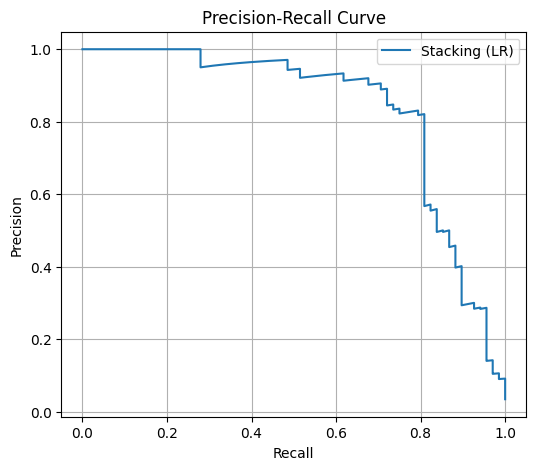

In [ ]:
plt.figure(figsize=(6,5))

plt.plot(recall, precision, label="Stacking (LR)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
import numpy as np

# Calculate F1 score for every threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# Find best threshold index
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]

print("Best Threshold:", round(best_threshold, 4))
print("Best F1 Score:", round(best_f1, 4))
print("Precision at Best Threshold:", round(best_precision, 4))
print("Recall at Best Threshold:", round(best_recall, 4))

Best Threshold: 0.9555
Best F1 Score: 0.8148
Precision at Best Threshold: 0.8209
Recall at Best Threshold: 0.8088


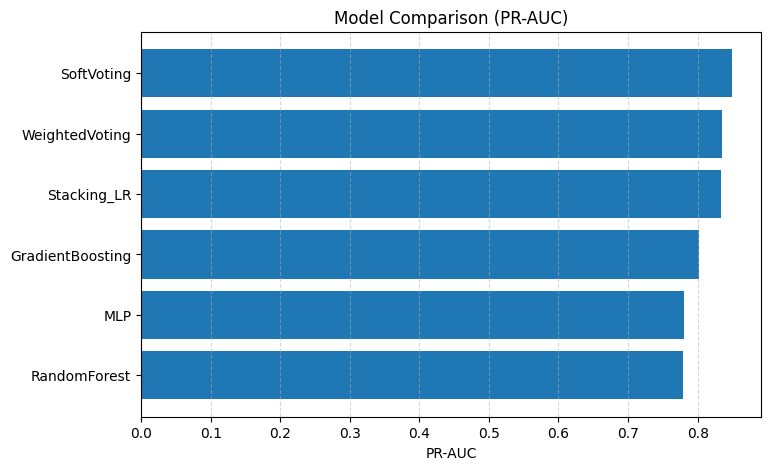

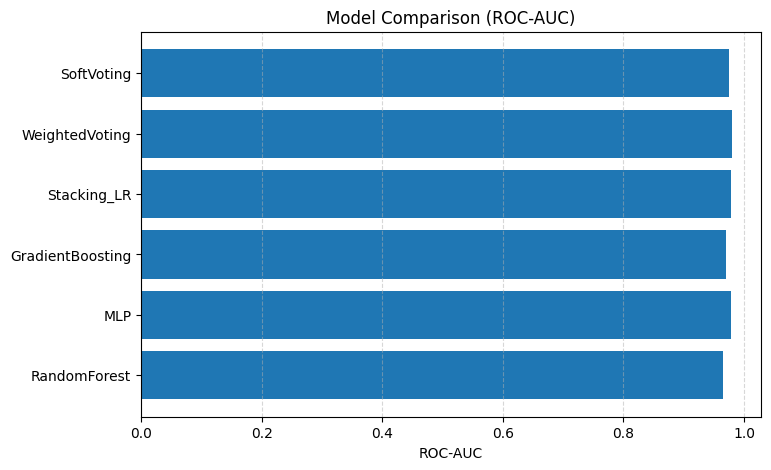

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Build a clean comparison table (remove duplicates if you reran cells)
results_df = pd.DataFrame(results).drop_duplicates(subset="model")

# Sort by PR-AUC (most important metric for imbalance)
results_df = results_df.sort_values("PR_AUC", ascending=True)

# --- PR-AUC bar plot ---
plt.figure(figsize=(8, 5))
plt.barh(results_df["model"], results_df["PR_AUC"])
plt.xlabel("PR-AUC")
plt.title("Model Comparison (PR-AUC)")
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.show()

# --- ROC-AUC bar plot ---
plt.figure(figsize=(8, 5))
plt.barh(results_df["model"], results_df["ROC_AUC"])
plt.xlabel("ROC-AUC")
plt.title("Model Comparison (ROC-AUC)")
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.show()